# Syngo: LA Dilation

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import os

In [3]:
data_dir = 'data/dataset/Lee_Echo_Syngo'
adler = pd.read_csv(os.path.join(data_dir, 'Adler.csv'))
analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
analytics_study = pd.read_csv(os.path.join(data_dir, 'AnalyticsStudy.csv'))
department = pd.read_csv(os.path.join(data_dir, 'Department.csv'))
field_map = pd.read_csv(os.path.join(data_dir, 'FieldMap.csv'))
measurement_type = pd.read_csv(os.path.join(data_dir, 'MeasurementType.csv'))
modalities = pd.read_csv(os.path.join(data_dir, 'Modalities.csv'))
observations = pd.read_csv(os.path.join(data_dir, 'Observations.csv'))
study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))

/tmp/ipykernel_3291/1852141919.py:3: DtypeWarning: Columns (18,19,23,24,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
/tmp/ipykernel_3291/1852141919.py:10: DtypeWarning: Columns (6,7,8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))


In [4]:
aws_uhn = pd.read_csv('aws/aws_uhn.csv', index_col=0)
print(aws_uhn.shape)

(320854, 9)


In [5]:
syn_df = observations.loc[observations['Name'] == 'LA_size-ASE_obs']
syn_df = syn_df.dropna(subset=['Value'])

In [6]:
syn_df.head()

,StudyRef,ObservationID,Value,Type,Name
23,1000750,54,severely_dilated,ABNORMAL,LA_size-ASE_obs
72,1000751,54,dilated,OTHER,LA_size-ASE_obs
88,1000846,54,normal,OTHER,LA_size-ASE_obs
198,1000712,54,moderately_dilated,ABNORMAL,LA_size-ASE_obs
338,1000715,54,dilated,OTHER,LA_size-ASE_obs


In [7]:
print(len(syn_df))
syn_df['Value'].value_counts()

89642


Value
normal                44780
dilated               19669
mildly_dilated        10772
severely_dilated       8089
moderately_dilated     3922
cardiac_transplant     2410
Name: count, dtype: int64

In [8]:
# list of values to drop
values_to_drop = ['cardiac_transplant', 'dilated']

# filter the DataFrame
syn_df = syn_df[~syn_df['Value'].isin(values_to_drop)]

mapping_binary = {
    'normal': 'normal',
    # 'dilated': 'dilated',
    'mildly_dilated': 'normal',
    'severely_dilated': 'dilated',
    'moderately_dilated': 'dilated',
}

In [9]:
label_col = 'LA_Dilated_Binary'
syn_df[label_col] = syn_df['Value'].map(mapping_binary)

In [10]:
print(len(syn_df))
syn_df[label_col].value_counts()

67563


LA_Dilated_Binary
normal     55552
dilated    12011
Name: count, dtype: int64

In [11]:
# Create a boolean mask to identify matching StudyRef values
matching_mask = syn_df['StudyRef'].isin(aws_uhn['STUDY_REF'])

# Count the number of matches (True values)
number_of_matches = matching_mask.sum()

# Get the total number of unique studies in mv_obs for context
total_unique_studies = syn_df['StudyRef'].nunique()

print(f"\nTotal unique StudyRef values in syn_df: {total_unique_studies}")
print(f"Number of 'StudyRef' values from syn_df that are in aws_uhn: {number_of_matches}")
print(f"Percentage of matching studies: {(number_of_matches / total_unique_studies) * 100:.2f}%")


Total unique StudyRef values in syn_df: 66700
Number of 'StudyRef' values from syn_df that are in aws_uhn: 32952
Percentage of matching studies: 49.40%


In [12]:
import pandas as pd

# Assuming 'mv_obs' and 'aws_uhn' are your DataFrames loaded as in the screenshots.

# Step 1: Merge the two DataFrames
# We'll merge 'mv_obs' with 'aws_uhn' using 'StudyRef' and 'STUDY_REF' as the keys.
merged_df = pd.merge(syn_df, aws_uhn, left_on='StudyRef', right_on='STUDY_REF', how='inner')

# Step 2: Define the desired columns in the correct order
final_columns = [
    'STUDY_REF',
    's3_key',
    'Value',
    label_col,
    'PATIENT_ID',
    'STUDY_DATE',
    'STUDY_TIME',
    'DeidentifiedStudyID',
    'OriginalStudyID'
]

# # Step 3: Create the new table with only the specified columns
syn_df_labels = merged_df[final_columns]

# convert numeric date to datetime
syn_df_labels['STUDY_DATE'] = pd.to_datetime(
    syn_df_labels['STUDY_DATE'].astype(str), 
    format='%Y%m%d'
)

# now sortable by date
syn_df_labels = syn_df_labels.sort_values('STUDY_DATE')
syn_df_labels['STUDY_DATE'] = syn_df_labels['STUDY_DATE'].dt.strftime('%Y-%m-%d')

/tmp/ipykernel_3291/1878314981.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  syn_df_labels['STUDY_DATE'] = pd.to_datetime(


In [13]:
print(syn_df_labels.shape)
print(syn_df_labels[label_col].value_counts())
print(syn_df_labels.columns)
display(syn_df_labels.head())

(33586, 9)
LA_Dilated_Binary
normal     27133
dilated     6453
Name: count, dtype: int64
Index(['STUDY_REF', 's3_key', 'Value', 'LA_Dilated_Binary', 'PATIENT_ID',
       'STUDY_DATE', 'STUDY_TIME', 'DeidentifiedStudyID', 'OriginalStudyID'],
      dtype='object')


,STUDY_REF,s3_key,Value,LA_Dilated_Binary,PATIENT_ID,STUDY_DATE,STUDY_TIME,DeidentifiedStudyID,OriginalStudyID
0,1000750,echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089/,severely_dilated,dilated,2132997,2015-07-22,80635.0,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,1.3.12.2.1107.5.8.9.1002655211149138.20150722120043279
28,1001175,echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1725195914.3248862/,normal,normal,4245026,2015-07-22,131611.0,1.2.276.0.7230010.3.1.2.895627313.1.1725195914.3248862,1.3.12.2.1107.5.8.9.1002655211149138.20150722131904569
29,1001010,echo-study-2/1.2.276.0.7230010.3.1.2.1667523124.1.1725196097.2345145/,mildly_dilated,normal,4192307,2015-07-22,102611.0,1.2.276.0.7230010.3.1.2.1667523124.1.1725196097.2345145,1.3.12.2.1107.5.8.9.1002655211149138.20150722142518560
30,1001014,echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1725196136.4283950/,severely_dilated,dilated,0167596,2015-07-22,105144.0,1.2.276.0.7230010.3.1.2.895693665.1.1725196136.4283950,1.3.12.2.1107.5.8.9.1002655211149138.20150722143943610
31,1001196,echo-study-2/1.2.276.0.7230010.3.1.2.1667523124.1.1725196548.2346639/,severely_dilated,dilated,3536094,2015-07-22,135627.0,1.2.276.0.7230010.3.1.2.1667523124.1.1725196548.2346639,1.3.12.2.1107.5.8.9.1002655211149138.20150722173350320


# HeartLab: LA Dilation

In [14]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import os

In [15]:
data_dir = 'data/dataset'

msmt_defs = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_DEFINITIONS.csv'))
msmt_formula = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_FORMULA.csv'))
msmt_groups = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_GROUPS.csv'))
msmt_intersects = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_INTERSECTS.csv'))
msmt_lists = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_LISTS.csv'))
msmt = pd.read_csv(os.path.join(data_dir,'MEASUREMENTS.csv'))

findings = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDINGS.csv'))
finding_groups = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDING_GROUPS.csv'))
finding_intersects = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDING_INTERSECTS.csv'))

patients = pd.read_csv(os.path.join(data_dir,'Patients_No_PHI.csv'))
reports = pd.read_csv(os.path.join(data_dir,'REPORTS.csv'))
series = pd.read_csv(os.path.join(data_dir,'SERIES.csv'))
studies = pd.read_csv(os.path.join(data_dir,'STUDIES.csv'))

/tmp/ipykernel_3291/2801898404.py:6: DtypeWarning: Columns (7,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  msmt_intersects = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_INTERSECTS.csv'))
/tmp/ipykernel_3291/2801898404.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  reports = pd.read_csv(os.path.join(data_dir,'REPORTS.csv'))
/tmp/ipykernel_3291/2801898404.py:16: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  series = pd.read_csv(os.path.join(data_dir,'SERIES.csv'))
/tmp/ipykernel_3291/2801898404.py:17: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  studies = pd.read_csv(os.path.join(data_dir,'STUDIES.csv'))


In [16]:
hl_link = pd.read_csv(os.path.join(data_dir, 'heartlab_rep_study_video.csv'))

In [17]:
hl_link.head()

,OriginalStudyID,OriginalPatientID,DeidentifiedStudyID,DeidentifiedPatientID,REP_ID,STUDY_DATE,STUDY_ID,SERI_ID,STUDY_INSTANCE_UID
0,1.2.840.113543.6.6.2.0.97083308851.20060302142809,3266450,1.2.276.0.7230010.3.1.2.1714578744.1.1703334530.11867061,00877fe5-b4ab-4df8-b6f1-68b947cec98d,81653.0,03/02/06 14:47:59,85175,167669,1.2.840.113543.6.6.2.0.97083308851.20060302142809
1,1.2.840.113663.1500.1.323664363.1.1.20140731.71250.953,2373936,1.2.276.0.7230010.3.1.2.1714512485.1.1703517296.18188851,8f9ab5ad-e865-4896-848b-dace75487884,352424.0,07/31/14 07:12:50,429897,849808,1.2.840.113663.1500.1.323664363.1.1.20140731.71250.953
2,1.2.840.113663.1500.1.251138317.1.1.20101020.145112.968,3400831,1.2.276.0.7230010.3.1.2.845494328.1.1703473583.20140024,62e5a193-0393-4210-9bd6-852d361f4734,243023.0,10/20/10 14:51:12,257826,504445,1.2.840.113663.1500.1.251138317.1.1.20101020.145112.968
3,1.2.840.113619.2.185.2475.1288968365.0.2,2866816,1.2.276.0.7230010.3.1.2.859333938.1.1703349794.12277579,a06b4a83-3fc9-4c10-ad01-fab2d52d9b6d,244657.0,11/05/10 09:46:05,259779,508538,1.2.840.113619.2.185.2475.1288968365.0.2
4,1.2.840.113619.2.185.2551.1376654311.0.2,2003428,1.2.276.0.7230010.3.1.2.811753780.1.1703356738.12653270,c204d4f9-2acb-463d-85fb-8a659ff9221b,324231.0,08/16/13 12:58:31,363739,756286,1.2.840.113619.2.185.2551.1376654311.0.2


In [18]:
aws_heartlab = pd.read_csv('aws/aws_heartlab_0806.csv', index_col=0)
print(aws_heartlab.shape)

(215113, 12)


In [19]:
finding_intersects = finding_intersects.merge(
    findings[['ID', 'HLCODE']], 
    left_on='FIN_ID', 
    right_on='ID', 
    how='left'
).drop(columns='ID_y').rename(columns={'ID_x': 'ID'})


In [20]:
codes = finding_intersects['HLCODE'].str.strip().str.lower()
# hl_df = finding_intersects[codes.str.contains('tricuspid valve.*regurgitation', na=False)]
hl_df = finding_intersects[codes.str.contains('la cavity size', na=False)]

In [21]:
hl_df['HLCODE'].value_counts()

HLCODE
left atrium^morphology^la cavity size^normal                     44920
left atrium^morphology^la cavity size^mildly dilated             39163
left atrium^morphology^la cavity size^dilated                    23223
left atrium^morphology^la cavity size^moderately dilated         12696
local^left atrium^morphology^la cavity size^upper normal^1561     7541
left atrium^morphology^la cavity size^severely dilated            7018
left atrium^morphology^la cavity size^abnormally small              68
Name: count, dtype: int64

In [22]:
hl_df['HLCODE'].unique()

array(['left atrium^morphology^la cavity size^mildly dilated',
       'left atrium^morphology^la cavity size^normal',
       'left atrium^morphology^la cavity size^moderately dilated',
       'local^left atrium^morphology^la cavity size^upper normal^1561',
       'left atrium^morphology^la cavity size^dilated',
       'left atrium^morphology^la cavity size^severely dilated',
       'left atrium^morphology^la cavity size^abnormally small'],
      dtype=object)

In [23]:
keep = [
    'left atrium^morphology^la cavity size^mildly dilated',
    'left atrium^morphology^la cavity size^normal',
    'left atrium^morphology^la cavity size^moderately dilated',
    'local^left atrium^morphology^la cavity size^upper normal^1561',
    # 'left atrium^morphology^la cavity size^dilated',
    'left atrium^morphology^la cavity size^severely dilated'
]

hl_df = hl_df[hl_df['HLCODE'].isin(keep)].copy()

In [24]:
mapping_two = {
    'left atrium^morphology^la cavity size^mildly dilated': 'normal', # prev dilated
    'left atrium^morphology^la cavity size^normal': 'normal',
    'left atrium^morphology^la cavity size^moderately dilated': 'dilated',
    'local^left atrium^morphology^la cavity size^upper normal^1561': 'normal',
    # 'left atrium^morphology^la cavity size^dilated': 'dilated', # remove
    'left atrium^morphology^la cavity size^severely dilated': 'dilated'
}

hl_df[label_col] = hl_df['HLCODE'].map(mapping_two)

In [25]:
print(hl_df[label_col].dropna().value_counts())

LA_Dilated_Binary
normal     91624
dilated    19714
Name: count, dtype: int64


In [26]:
# REP_IDs that appear in the hl_df dataframe
hl_ids = hl_df['REP_ID'].dropna().unique()
print(len(hl_ids))

# Grab columns from the hl_link dataframes using REP_IDs
hl_df_labels = hl_link[hl_link['REP_ID'].isin(hl_ids)].copy()

111337


In [27]:
hl_df_labels = hl_df.merge(
    hl_df_labels,
    on='REP_ID',
    how='inner',
    suffixes=('', '_drop')  # keep REP_ID as-is, add suffix to duplicates
)

# Remove the duplicate REP_ID column if created
if 'REP_ID_drop' in hl_df_labels.columns:
    hl_df_labels = hl_df_labels.drop(columns=['REP_ID_drop'])

hl_df_labels = hl_df_labels.merge(
    aws_heartlab[['OriginalStudyID', 's3_key']],  # only needed columns
    on='OriginalStudyID',
    how='left'
)

hl_df_labels = hl_df_labels.dropna(subset=['s3_key'])

# convert STUDY_DATE to datetime objects
hl_df_labels['STUDY_DATE'] = pd.to_datetime(
    hl_df_labels['STUDY_DATE'], 
    format='%m/%d/%y %H:%M:%S'  # matches "01/20/09 10:29:09"
)



# now you can sort
hl_df_labels = hl_df_labels.sort_values('STUDY_DATE')
hl_df_labels['STUDY_DATE'] = hl_df_labels['STUDY_DATE'].dt.strftime('%Y-%m-%d')

hl_df_labels = hl_df_labels.rename(
    columns={'OriginalPatientID': 'PATIENT_ID'}
)

print(hl_df_labels.columns)
print(hl_df_labels.shape)
display(hl_df_labels.head())

Index(['ID', 'FIN_ID', 'PHAS_ID', 'NOTE', 'SEQA_ID', 'SEQB_ID', 'SEQC_ID',
       'REP_ID', 'SEQD_ID', 'STRUCTURE_GROUP_SEQ', 'HLCODE',
       'LA_Dilated_Binary', 'OriginalStudyID', 'PATIENT_ID',
       'DeidentifiedStudyID', 'DeidentifiedPatientID', 'STUDY_DATE',
       'STUDY_ID', 'SERI_ID', 'STUDY_INSTANCE_UID', 's3_key'],
      dtype='object')
(75167, 21)


,ID,FIN_ID,PHAS_ID,NOTE,SEQA_ID,SEQB_ID,SEQC_ID,REP_ID,SEQD_ID,STRUCTURE_GROUP_SEQ,HLCODE,LA_Dilated_Binary,OriginalStudyID,PATIENT_ID,DeidentifiedStudyID,DeidentifiedPatientID,STUDY_DATE,STUDY_ID,SERI_ID,STUDY_INSTANCE_UID,s3_key
123,15837,64,1,NaN,NaN,NaN,NaN,2734,NaN,NaN,left atrium^morphology^la cavity size^mildly dilated,normal,1.2.840.113619.2.98.1722.1076392656.0.953,2988134,1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,871c4367-6320-494b-8567-2052a62ce9a3,2004-02-10,27370,29195,1.2.840.113619.2.98.1722.1076392656.0.953,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940/
1112,270151,62,1,NaN,NaN,NaN,NaN,16908,NaN,NaN,left atrium^morphology^la cavity size^normal,normal,1.2.840.113663.1298.56555945.1.8341.20040706.1112016,1051718,1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064,b183fe1a-566f-4b01-b49d-90ee44b0f078,2004-07-06,38087,47498,1.2.840.113663.1298.56555945.1.8341.20040706.1112016,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064/
1111,270317,62,1,NaN,NaN,NaN,NaN,16918,NaN,NaN,left atrium^morphology^la cavity size^normal,normal,1.2.840.113663.1298.56555945.1.26060.20040706.1130203,3000666,1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584,0ed3ee1a-ee01-45f7-92fd-96eac5045ffc,2004-07-06,38096,47514,1.2.840.113663.1298.56555945.1.26060.20040706.1130203,echo-study/1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584/
1120,285789,62,1,NaN,NaN,NaN,NaN,17671,NaN,NaN,left atrium^morphology^la cavity size^normal,normal,1.2.840.113680.1.103.51602.1089741645.391708,3149598,1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674,73e46460-bbcb-4907-9291-25428a8e913d,2004-07-13,38600,48390,1.2.840.113680.1.103.51602.1089741645.391708,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674/
1114,301450,62,1,NaN,NaN,NaN,NaN,18494,NaN,NaN,left atrium^morphology^la cavity size^normal,normal,1.2.840.113663.1298.56555945.1.27595.20040721.1102059,2333731,1.2.276.0.7230010.3.1.2.859333938.1.1703408030.13804843,ca2624a4-93bb-402b-8255-0e8a905fee00,2004-07-21,39214,49461,1.2.840.113663.1298.56555945.1.27595.20040721.1102059,echo-study/1.2.276.0.7230010.3.1.2.859333938.1.1703404409.13766429/


# Combine

In [28]:
# Columns you want to keep
keep_cols = [
    'STUDY_REF','REP_ID','HLCODE', 'Value', label_col ,'s3_key',  'STUDY_DATE',
    'STUDY_TIME', 'DeidentifiedStudyID', 'OriginalStudyID',
    'PATIENT_ID', 'DeidentifiedPatientID', 'SERI_ID', 'STUDY_ID',
    'STUDY_INSTANCE_UID'
]

# Combine both dataframes
uhn_df = pd.concat([syn_df_labels, hl_df_labels], ignore_index=True, sort=False)

# Drop overlapping OriginalStudyIDs (keep first occurrence)
uhn_df = uhn_df.drop_duplicates(subset='OriginalStudyID', keep='first')

# Restrict to selected columns
uhn_df = uhn_df.reindex(columns=keep_cols)

# Drop rows where there is no s3 key
uhn_df = uhn_df.dropna(subset=['s3_key'])

# Ensure STUDY_DATE is datetime before sorting
uhn_df['STUDY_DATE'] = pd.to_datetime(uhn_df['STUDY_DATE'], errors='coerce')

# Sort by STUDY_DATE (earliest first)
uhn_df = uhn_df.sort_values('STUDY_DATE')

print(uhn_df.shape)
display(uhn_df.head())


(107587, 15)


,STUDY_REF,REP_ID,HLCODE,Value,LA_Dilated_Binary,s3_key,STUDY_DATE,STUDY_TIME,DeidentifiedStudyID,OriginalStudyID,PATIENT_ID,DeidentifiedPatientID,SERI_ID,STUDY_ID,STUDY_INSTANCE_UID
33586,NaN,2734.0,left atrium^morphology^la cavity size^mildly dilated,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940/,2004-02-10,NaN,1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,1.2.840.113619.2.98.1722.1076392656.0.953,2988134,871c4367-6320-494b-8567-2052a62ce9a3,29195.0,27370.0,1.2.840.113619.2.98.1722.1076392656.0.953
33587,NaN,16908.0,left atrium^morphology^la cavity size^normal,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064/,2004-07-06,NaN,1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064,1.2.840.113663.1298.56555945.1.8341.20040706.1112016,1051718,b183fe1a-566f-4b01-b49d-90ee44b0f078,47498.0,38087.0,1.2.840.113663.1298.56555945.1.8341.20040706.1112016
33588,NaN,16918.0,left atrium^morphology^la cavity size^normal,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584/,2004-07-06,NaN,1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584,1.2.840.113663.1298.56555945.1.26060.20040706.1130203,3000666,0ed3ee1a-ee01-45f7-92fd-96eac5045ffc,47514.0,38096.0,1.2.840.113663.1298.56555945.1.26060.20040706.1130203
33589,NaN,17671.0,left atrium^morphology^la cavity size^normal,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674/,2004-07-13,NaN,1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674,1.2.840.113680.1.103.51602.1089741645.391708,3149598,73e46460-bbcb-4907-9291-25428a8e913d,48390.0,38600.0,1.2.840.113680.1.103.51602.1089741645.391708
33591,NaN,18487.0,left atrium^morphology^la cavity size^mildly dilated,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.811753780.1.1703536322.15218101/,2004-07-21,NaN,1.2.276.0.7230010.3.1.2.811753780.1.1703536322.15218101,1.2.840.113680.1.103.51602.1090424297.231764,2188311,bd11a763-788a-4a74-a5c2-7c9d00739c64,49454.0,39213.0,1.2.840.113680.1.103.51602.1090424297.231764


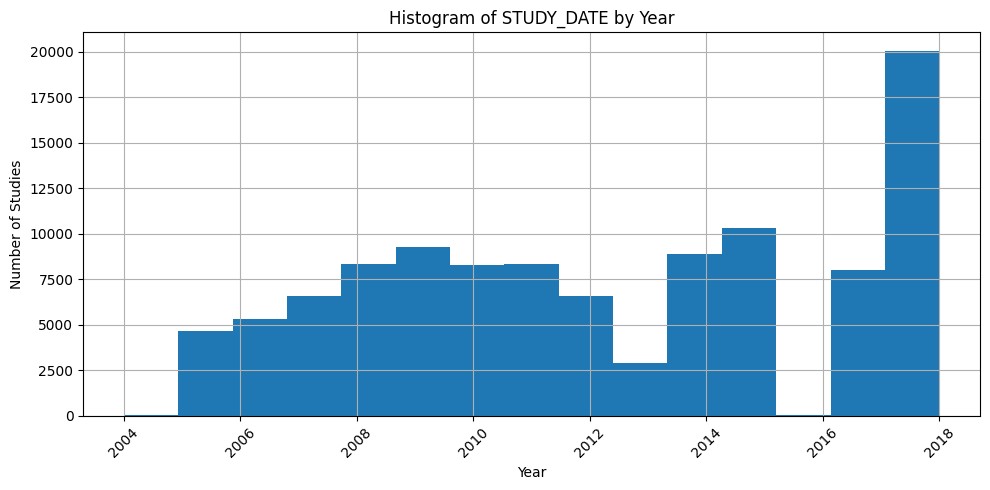

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure STUDY_DATE is datetime
uhn_df['STUDY_DATE'] = pd.to_datetime(uhn_df['STUDY_DATE'], errors='coerce')

# Extract year
uhn_df['YEAR'] = uhn_df['STUDY_DATE'].dt.year

# Plot histogram
plt.figure(figsize=(10,5))
uhn_df['YEAR'].dropna().astype(int).hist(bins=uhn_df['YEAR'].nunique())
plt.xlabel('Year')
plt.ylabel('Number of Studies')
plt.title('Histogram of STUDY_DATE by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Final label counts for the selected condition
uhn_df[label_col].value_counts()

LA_Dilated_Binary
normal     88849
dilated    18738
Name: count, dtype: int64

In [31]:
# uhn_df.to_csv('csv/uhn_lad_0919.csv')
uhn_df.to_csv('csv/uhn_lad_0922.csv')

# Create Splits

In [32]:
import pandas as pd
from pathlib import Path

all_es = pd.read_parquet('all_es_combined.parquet')

In [33]:
# Create a new DataFrame called 'a4c_df' by filtering 'all_es'
# all_es = combined_df
a4c_videos = all_es[all_es['pred_view'] == 'a4c'].copy()

# This regex finds 'echo-study', 'echo-study-1', or 'echo-study-2',
# and then captures the sequence of characters that follows until the next slash.
regex_pattern = r'results/echo-study(?:-[12])?/([^/]+)'

# Use .str.extract() to pull out the captured group (the Study ID)
a4c_videos['DeidentifiedStudyID'] = a4c_videos['png_uri'].str.extract(regex_pattern)

a4c_videos = a4c_videos[['DeidentifiedStudyID', 'mp4_uri_corrected']].rename(
    columns={'mp4_uri_corrected': 'URI'}
)

In [34]:
print(a4c_videos.shape)
display(a4c_videos.head())

(2976025, 2)


,DeidentifiedStudyID,URI
3,1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111392.10353346.mp4
5,1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773/1.2.276.0.7230010.3.1.3.1714512485.1.1703119859.10459774/1.2.276.0.7230010.3.1.4.1714512485.1.1703120151.10464936.mp4
9,1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.811753780.1.1703111413.8215093.mp4
11,1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.811753780.1.1703111387.8215053.mp4
13,1.2.276.0.7230010.3.1.2.1714512485.1.1703113062.10354034,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703113062.10354034/1.2.276.0.7230010.3.1.3.1714512485.1.1703113062.10354035/1.2.276.0.7230010.3.1.4.1714512485.1.1703113992.10362168.mp4


In [35]:
# combined_labels = pd.read_csv('csv/uhn_lad_0919.csv')
combined_labels = pd.read_csv('csv/uhn_lad_0922.csv')

/tmp/ipykernel_3291/3636336959.py:2: DtypeWarning: Columns (3,4,11,12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_labels = pd.read_csv('csv/uhn_lad_0922.csv')


In [36]:
# Select only the necessary columns from your labels DataFrame for efficiency
labels_to_merge = combined_labels[['DeidentifiedStudyID', 'STUDY_DATE', 'PATIENT_ID', label_col]]

# Merge the two DataFrames to find the overlap and add the 'Value'
# 'how="inner"' ensures only matching DeidentifiedStudyIDs are kept
a4c_dataset = pd.merge(
    a4c_videos, 
    labels_to_merge, 
    on='DeidentifiedStudyID', 
    how='inner'
)

print(f"Found {len(a4c_dataset)} A4C videos.")
a4c_dataset.head()

Found 1058815 A4C videos.


,DeidentifiedStudyID,URI,STUDY_DATE,PATIENT_ID,LA_Dilated_Binary
0,1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773/1.2.276.0.7230010.3.1.3.1714512485.1.1703119859.10459774/1.2.276.0.7230010.3.1.4.1714512485.1.1703120151.10464936.mp4,2014-04-22,2044684,normal
1,1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672/1.2.276.0.7230010.3.1.3.845494328.1.1703118950.13422692/1.2.276.0.7230010.3.1.4.845494328.1.1703119427.13430962.mp4,2014-04-07,4146782,dilated
2,1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672/1.2.276.0.7230010.3.1.3.845494328.1.1703118950.13422692/1.2.276.0.7230010.3.1.4.859333938.1.1703119471.8098703.mp4,2014-04-07,4146782,dilated
3,1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672/1.2.276.0.7230010.3.1.3.845494328.1.1703118950.13422692/1.2.276.0.7230010.3.1.4.1714512485.1.1703119575.10454529.mp4,2014-04-07,4146782,dilated
4,1.2.276.0.7230010.3.1.2.1714512485.1.1703116096.10392649,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703116096.10392649/1.2.276.0.7230010.3.1.3.1714512485.1.1703116096.10392650/1.2.276.0.7230010.3.1.4.859333938.1.1703116614.8054524.mp4,2014-03-26,3827152,normal


# New Splitting

In [37]:
len(a4c_dataset)

1058815

In [43]:
a4c_dataset.head()

,DeidentifiedStudyID,URI,STUDY_DATE,PATIENT_ID,LA_Dilated_Binary
0,1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773/1.2.276.0.7230010.3.1.3.1714512485.1.1703119859.10459774/1.2.276.0.7230010.3.1.4.1714512485.1.1703120151.10464936.mp4,2014-04-22,2044684,normal
1,1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672/1.2.276.0.7230010.3.1.3.845494328.1.1703118950.13422692/1.2.276.0.7230010.3.1.4.845494328.1.1703119427.13430962.mp4,2014-04-07,4146782,dilated
2,1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672/1.2.276.0.7230010.3.1.3.845494328.1.1703118950.13422692/1.2.276.0.7230010.3.1.4.859333938.1.1703119471.8098703.mp4,2014-04-07,4146782,dilated
3,1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672/1.2.276.0.7230010.3.1.3.845494328.1.1703118950.13422692/1.2.276.0.7230010.3.1.4.1714512485.1.1703119575.10454529.mp4,2014-04-07,4146782,dilated
4,1.2.276.0.7230010.3.1.2.1714512485.1.1703116096.10392649,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703116096.10392649/1.2.276.0.7230010.3.1.3.1714512485.1.1703116096.10392650/1.2.276.0.7230010.3.1.4.859333938.1.1703116614.8054524.mp4,2014-03-26,3827152,normal


In [44]:
a4c_dataset.columns

Index(['DeidentifiedStudyID', 'URI', 'STUDY_DATE', 'PATIENT_ID',
       'LA_Dilated_Binary'],
      dtype='object')

In [69]:
# Patient‑disjoint, forward‑chaining temporal split for A4C LA_Dilated_Binary (no required‑views)

from dataclasses import dataclass
from datetime import date
import os
import numpy as np
import pandas as pd

# ============== Config (edit to match your schema) ==============
# If your unique study key isn't "DeidentifiedStudyID", this will auto‑fallback to "URI".
STUDY_COL   = "DeidentifiedStudyID"   # will auto-fallback to "URI" if absent
PATIENT_COL = "PATIENT_ID"
DATE_COL    = "STUDY_DATE"

# Original label (raw) and normalized numeric label (0/1, Int64)
label_col   = "LA_Dilated_Binary"
LBL_COL     = "_LBL"

# Split params (applied on eligible/labeled patients ordered by first labeled date)
train_q      = 0.70
val_q        = 0.85
min_test_all = 2000    # reduce if this task is smaller
min_test_pos = 0       # set >0 if you want a minimum #positives in test
ERA_CUTOFF   = date(2015, 6, 1)

# ========================= Helpers ==============================
def _parse_date(x):
    if pd.isna(x):
        return None
    if isinstance(x, date):
        return x
    if isinstance(x, pd.Timestamp):
        return x.date()
    ts = pd.to_datetime(x, errors="coerce")
    return None if pd.isna(ts) else ts.date()

def _normalize_label_series(s: pd.Series) -> pd.Series:
    # Extend/adjust this mapping to your dataset if needed.
    mapping = {
        "normal": 0, "dilated": 1,
        "no": 0, "yes": 1, "y": 1, "n": 0,
        "false": 0, "true": 1,
        True: 1, False: 0,
        0: 0, 1: 1, "0": 0, "1": 1,
    }
    out = s.map(lambda v: mapping.get(v if not isinstance(v, str) else v.strip().lower(), v))
    return pd.to_numeric(out, errors="coerce").astype("Int64")

def _canon_pid_series(s: pd.Series) -> pd.Series:
    # Canonicalize exactly as used in checks: strip + drop trailing ".0"
    return (
        s.astype("string")
         .str.strip()
         .str.replace(r"\.0$", "", regex=True)
    )

@dataclass
class SplitArgs:
    train_q: float = 0.70
    val_q: float   = 0.85
    min_test: int  = 2000
    min_pos_test: int = 0

def _eligible_patients(df: pd.DataFrame, lbl: str) -> pd.DataFrame:
    # Eligible = has normalized label + date + patient; anchor = first labeled study date per patient
    keep = df[lbl].notna() & df[DATE_COL].notna() & df[PATIENT_COL].notna()
    d = df.loc[keep, [PATIENT_COL, DATE_COL]].copy()
    d[PATIENT_COL] = _canon_pid_series(d[PATIENT_COL])
    d[DATE_COL] = d[DATE_COL].map(_parse_date)
    d = d.dropna(subset=[DATE_COL])
    anchor = (
        d.groupby(PATIENT_COL, as_index=False)[DATE_COL]
        .min()
        .rename(columns={DATE_COL: "ANCHOR_DATE"})
    )
    # Sort strictly by ANCHOR_DATE (primary) and PATIENT_ID (secondary) for stability
    anchor = anchor.sort_values(["ANCHOR_DATE", PATIENT_COL], kind="mergesort").reset_index(drop=True)
    return anchor  # columns: PATIENT_ID, ANCHOR_DATE

def _attach_and_clip(df: pd.DataFrame, pat_bins: pd.DataFrame, lbl: str, val_cut: date, test_cut: date):
    d = df.copy()
    d[PATIENT_COL] = _canon_pid_series(d[PATIENT_COL])
    b = pat_bins.copy()
    b[PATIENT_COL] = _canon_pid_series(b[PATIENT_COL])

    m = d.merge(b, on=PATIENT_COL, how="inner")
    m = m.loc[m[lbl].notna() & m[DATE_COL].notna()].copy()
    m[DATE_COL] = m[DATE_COL].map(_parse_date)
    m = m.dropna(subset=[DATE_COL])

    train_mask = (m["SPLIT"] == "train") & (m[DATE_COL] <  val_cut)
    val_mask   = (m["SPLIT"] == "val")   & (m[DATE_COL] >= val_cut) & (m[DATE_COL] <  test_cut)
    test_mask  = (m["SPLIT"] == "test")  & (m[DATE_COL] >= test_cut)

    m = m.loc[train_mask | val_mask | test_mask].copy()

    # Ensure each patient remains in exactly one split
    if len(m):
        assert (m.groupby(PATIENT_COL)["SPLIT"].nunique() == 1).all(), "Leakage: a patient appears in multiple splits."

    return (
        m.loc[m["SPLIT"] == "train"].copy(),
        m.loc[m["SPLIT"] == "val"].copy(),
        m.loc[m["SPLIT"] == "test"].copy()
    )

def _split_task(a4c_df: pd.DataFrame, lbl: str, args: SplitArgs):
    elig = _eligible_patients(a4c_df, lbl)
    n = len(elig)
    if n == 0:
        raise RuntimeError("No eligible A4C patients with label+date.")

    # Initial cut by patient order (chronological by ANCHOR_DATE)
    i1, i2 = int(round(args.train_q*n)), int(round(args.val_q*n))
    i1 = max(1, min(i1, n-2))
    i2 = max(i1+1, min(i2, n-1))

    def assign_bins(e: pd.DataFrame, i1: int, i2: int) -> pd.DataFrame:
        idx = np.arange(len(e))
        bins = np.where(idx < i1, "train", np.where(idx < i2, "val", "test"))
        out = e.copy()
        out["SPLIT"] = bins
        return out[[PATIENT_COL, "SPLIT", "ANCHOR_DATE"]]

    def make_splits(i1_: int, i2_: int):
        pat_bins = assign_bins(elig, i1_, i2_)
        # Forward‑chaining global temporal cutoffs from patient anchors
        val_cut  = pat_bins.loc[pat_bins["SPLIT"] == "val",  "ANCHOR_DATE"].min()
        test_cut = pat_bins.loc[pat_bins["SPLIT"] == "test", "ANCHOR_DATE"].min()
        if pd.isna(val_cut) or pd.isna(test_cut):
            return None, None, None, None, None
        tr, va, te = _attach_and_clip(a4c_df, pat_bins[[PATIENT_COL, "SPLIT"]], lbl, val_cut, test_cut)
        return tr, va, te, val_cut, test_cut

    def counts_ok(tr: pd.DataFrame, va: pd.DataFrame, te: pd.DataFrame) -> bool:
        if te is None:
            return False
        if len(te) < args.min_test:
            return False
        if args.min_pos_test > 0:
            pos = (te[lbl].astype("Int64") == 1).sum()
            if pos < args.min_pos_test:
                return False
        return (len(tr) > 0) and (len(va) > 0)

    attempts = 0
    tr = va = te = None
    val_cut = test_cut = None

    while attempts < 200:
        tr, va, te, val_cut, test_cut = make_splits(i1, i2)
        if tr is not None and counts_ok(tr, va, te):
            break
        # If test too small, move earlier chronologically (expand test set)
        step = max(1, len(elig)//50)
        i1 = max(1, i1 - step)
        i2 = max(i1 + 1, i2 - step)
        attempts += 1

    if tr is None or va is None or te is None:
        raise RuntimeError("Failed to produce valid forward‑chaining splits with requested constraints.")

    # Sanity: strict temporal ordering at row level
    if len(tr) and len(va):
        assert tr[DATE_COL].max() <  va[DATE_COL].min(), "Temporal violation between train and val."
    if len(va) and len(te):
        assert va[DATE_COL].max() <  te[DATE_COL].min(),  "Temporal violation between val and test."

    # Sanity: patient‑disjoint
    for a_name, a_df in [("train", tr), ("val", va), ("test", te)]:
        A = set(_canon_pid_series(a_df[PATIENT_COL]))
        for b_name, b_df in [("train", tr), ("val", va), ("test", te)]:
            if a_name == b_name:
                continue
            inter = A & set(_canon_pid_series(b_df[PATIENT_COL]))
            assert not inter, f"Leakage between {a_name} and {b_name}: {len(inter)} patients"

    return tr, va, te, val_cut, test_cut

# ====================== Run on your A4C dataset ======================
# Expect `a4c_dataset` to be a DataFrame in your environment with at least:
# [study_id, PATIENT_ID, STUDY_DATE, LA_Dilated_Binary]
df = a4c_dataset.copy()  # noqa: F821  # ensure this DataFrame exists in your environment

# Auto‑select study id column if the configured one is missing
if STUDY_COL not in df.columns:
    if "URI" in df.columns:
        STUDY_COL = "URI"
    else:
        raise AssertionError(f"Missing unique study id column: '{STUDY_COL}' and fallback 'URI' not found.")

# Column presence
for c in [STUDY_COL, PATIENT_COL, DATE_COL, label_col]:
    assert c in df.columns, f"Missing column: {c}"

# Normalize fields (including canonicalized PATIENT_ID used everywhere and written out)
df[PATIENT_COL] = _canon_pid_series(df[PATIENT_COL])
df[DATE_COL] = df[DATE_COL].map(_parse_date)
df[LBL_COL] = _normalize_label_series(df[label_col])
df["ERA_POST_2015"] = df[DATE_COL].map(lambda d: (d is not None) and (d >= ERA_CUTOFF))

# Split on normalized label to avoid dtype issues
sargs = SplitArgs(train_q=train_q, val_q=val_q, min_test=min_test_all, min_pos_test=min_test_pos)
train_df, val_df, test_df, VAL_CUTOFF, TEST_CUTOFF = _split_task(
    df[[STUDY_COL, PATIENT_COL, DATE_COL, label_col, LBL_COL, "ERA_POST_2015"]],
    LBL_COL,
    sargs
)

# =========================== Outputs ================================
base = f"a4c_{label_col}"
cols = [STUDY_COL, PATIENT_COL, DATE_COL, "ERA_POST_2015", label_col, LBL_COL]

# De‑duplicate by study id to ensure one row per study in files
train_df[cols].drop_duplicates(subset=[STUDY_COL]).to_csv(f"{base}_train.csv", index=False)
val_df[cols].drop_duplicates(subset=[STUDY_COL]).to_csv(f"{base}_val.csv", index=False)
test_df[cols].drop_duplicates(subset=[STUDY_COL]).to_csv(f"{base}_test.csv", index=False)

all_splits = pd.concat(
    [
        train_df.assign(SPLIT="train"),
        val_df.assign(SPLIT="val"),
        test_df.assign(SPLIT="test"),
    ],
    ignore_index=True,
)

(all_splits[cols + ["SPLIT"]]
 .drop_duplicates(subset=[STUDY_COL])
 .to_csv(f"{base}_splits.csv", index=False))

# ===================== Summary + checks =============================
def _summarize(df_, tag):
    n = len(df_)
    pos = (df_[LBL_COL].astype("Int64") == 1).sum()
    pid_n = _canon_pid_series(df_[PATIENT_COL]).nunique()
    pos_rate = (pos / n) if n else 0.0
    print(f"{tag:5s}: rows={n:6d}  pos={pos:6d}  pos_rate={pos_rate:.3f}  patients={pid_n:6d}")

print("\n== A4C LA Dilation (forward‑chaining, patient‑disjoint) ==")
print(f"VAL_CUTOFF : {VAL_CUTOFF}")
print(f"TEST_CUTOFF: {TEST_CUTOFF}")
_summarize(train_df, "train")
_summarize(val_df,   "val")
_summarize(test_df,  "test")

# Temporal integrity (max(train) < min(val) < min(test))
if len(train_df) and len(val_df):
    print("train_max_date:", train_df[DATE_COL].max(), " < val_min_date:", val_df[DATE_COL].min())
if len(val_df) and len(test_df):
    print("val_max_date  :", val_df[DATE_COL].max(),   " < test_min_date:", test_df[DATE_COL].min())

print("\nWrote:")
for f in [f"{base}_train.csv", f"{base}_val.csv", f"{base}_test.csv", f"{base}_splits.csv"]:
    print("  -", os.path.abspath(f))



== A4C LA Dilation (forward‑chaining, patient‑disjoint) ==
VAL_CUTOFF : 2015-07-29
TEST_CUTOFF: 2018-03-02
train: rows=702452  pos=126689  pos_rate=0.180  patients= 45748
val  : rows=116528  pos= 20439  pos_rate=0.175  patients=  9762
test : rows=121551  pos= 26178  pos_rate=0.215  patients=  9803
train_max_date: 2015-07-28  < val_min_date: 2015-07-29
val_max_date  : 2018-03-01  < test_min_date: 2018-03-02

Wrote:
  - /mnt/custom-file-systems/efs/fs-0049217cdf69186d7_fsap-0fa7145b64eaa046b/vjepa2/data/a4c_LA_Dilated_Binary_train.csv
  - /mnt/custom-file-systems/efs/fs-0049217cdf69186d7_fsap-0fa7145b64eaa046b/vjepa2/data/a4c_LA_Dilated_Binary_val.csv
  - /mnt/custom-file-systems/efs/fs-0049217cdf69186d7_fsap-0fa7145b64eaa046b/vjepa2/data/a4c_LA_Dilated_Binary_test.csv
  - /mnt/custom-file-systems/efs/fs-0049217cdf69186d7_fsap-0fa7145b64eaa046b/vjepa2/data/a4c_LA_Dilated_Binary_splits.csv


# Check

In [70]:
# Simple overlap check (current working directory)

import pandas as pd

PATIENT_COL = "PATIENT_ID"
paths = {
    "train": "a4c_LA_Dilated_Binary_train.csv",
    "val":   "a4c_LA_Dilated_Binary_val.csv",
    "test":  "a4c_LA_Dilated_Binary_test.csv",
}

def canon_pid_series(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
         .str.strip()
         .str.replace(r"\.0$", "", regex=True)
    )

def read_ids(p):
    df = pd.read_csv(p, dtype={PATIENT_COL: "string"}, keep_default_na=False)
    s = canon_pid_series(df[PATIENT_COL])
    return set(s)

S_tr, S_va, S_te = map(read_ids, paths.values())
print("train∩val:", len(S_tr & S_va))
print("train∩test:", len(S_tr & S_te))
print("val∩test:", len(S_va & S_te))  # should be 0


train∩val: 0
train∩test: 0
val∩test: 0


Patient overlaps (per-file):
  train ∩ val : 0
  train ∩ test: 0
  val   ∩ test: 86

Study overlaps (per-file):
  train ∩ val : 0
  train ∩ test: 0
  val   ∩ test: 0

Consolidated-file offenders (patients in >1 split): 0

Patient-level FIRST_DATE stats:
  train: {'min': Timestamp('2004-02-10 00:00:00'), 'median': Timestamp('2010-03-12 00:00:00'), 'max': Timestamp('2015-07-28 00:00:00')}
  val  : {'min': Timestamp('2015-07-29 00:00:00'), 'median': Timestamp('2017-10-11 00:00:00'), 'max': Timestamp('2018-03-01 00:00:00')}
  test : {'min': Timestamp('2018-03-02 00:00:00'), 'median': Timestamp('2018-07-24 00:00:00'), 'max': Timestamp('2018-12-05 00:00:00')}
Temporal (patient-level forward shift): OK


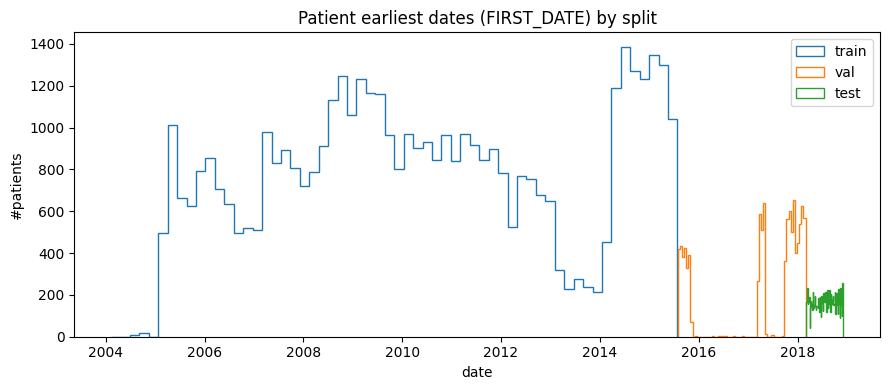

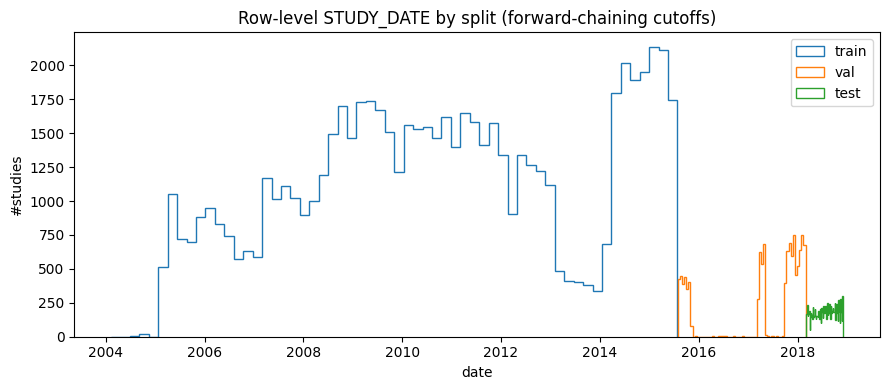

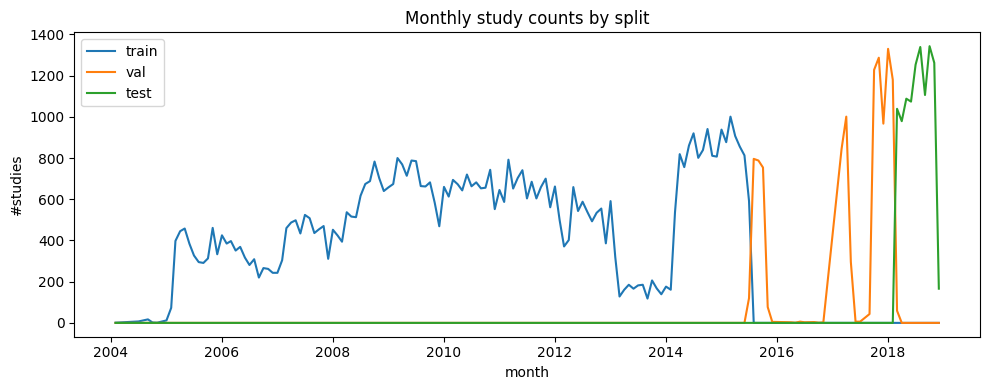

In [71]:
# Extended integrity checks (reads from a base directory)

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

def canon_pid_series(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
         .str.strip()
         .str.replace(r"\.0$", "", regex=True)
    )

base_dir = Path("/mnt/custom-file-systems/efs/fs-0049217cdf69186d7_fsap-0fa7145b64eaa046b/vjepa2/data")
base = "a4c_LA_Dilated_Binary"

tr = pd.read_csv(base_dir / f"{base}_train.csv", parse_dates=["STUDY_DATE"])
va = pd.read_csv(base_dir / f"{base}_val.csv",   parse_dates=["STUDY_DATE"])
te = pd.read_csv(base_dir / f"{base}_test.csv",  parse_dates=["STUDY_DATE"])
all_splits = pd.read_csv(base_dir / f"{base}_splits.csv", parse_dates=["STUDY_DATE"])

# Canonicalize patient IDs exactly as in splitter
for df in (tr, va, te, all_splits):
    df["PATIENT_ID"] = canon_pid_series(df["PATIENT_ID"])

# Auto-detect study id column for overlap checks
STUDY_COL = "DeidentifiedStudyID" if "DeidentifiedStudyID" in tr.columns else ("URI" if "URI" in tr.columns else None)
if STUDY_COL is None:
    raise AssertionError("Missing unique study id column in split files (expected 'DeidentifiedStudyID' or 'URI').")

# Per-file patient set intersections
pt_tr, pt_va, pt_te = set(tr["PATIENT_ID"]), set(va["PATIENT_ID"]), set(te["PATIENT_ID"])
print("Patient overlaps (per-file):")
print("  train ∩ val :", len(pt_tr & pt_va))
print("  train ∩ test:", len(pt_tr & pt_te))
print("  val   ∩ test:", len(pt_va & pt_te))

# Study-level overlaps across files (should be 0 after per-file de-dup)
st_tr, st_va, st_te = set(tr[STUDY_COL]), set(va[STUDY_COL]), set(te[STUDY_COL])
print("\nStudy overlaps (per-file):")
print("  train ∩ val :", len(st_tr & st_va))
print("  train ∩ test:", len(st_tr & st_te))
print("  val   ∩ test:", len(st_va & st_te))

# Consolidated-file offenders (patients in >1 split)
per_patient_splits = all_splits.groupby("PATIENT_ID")["SPLIT"].nunique()
n_off = int((per_patient_splits > 1).sum())
print("\nConsolidated-file offenders (patients in >1 split):", n_off)

if n_off > 0:
    offenders = per_patient_splits[per_patient_splits > 1].index.tolist()
    print("Example offender IDs:", offenders[:10])
    dbg = (all_splits[all_splits["PATIENT_ID"].isin(offenders)]
             .sort_values(["PATIENT_ID","STUDY_DATE"]))
    try:
        from IPython.display import display  # noqa: F401
        display(dbg.head(20))
    except Exception:
        print(dbg.head(20).to_string(index=False))

def earliest_by_patient(df):
    return (df.groupby("PATIENT_ID")["STUDY_DATE"]
              .min().rename("FIRST_DATE").reset_index())

e_train = earliest_by_patient(tr)
e_val   = earliest_by_patient(va)
e_test  = earliest_by_patient(te)

def stats(s):
    s = pd.to_datetime(s)
    return dict(min=s.min(), median=s.quantile(0.5), max=s.max())

print("\nPatient-level FIRST_DATE stats:")
print("  train:", stats(e_train["FIRST_DATE"]))
print("  val  :", stats(e_val["FIRST_DATE"]))
print("  test :", stats(e_test["FIRST_DATE"]))

# Boundaries should be non-overlapping at the patient level
train_max = pd.to_datetime(e_train["FIRST_DATE"]).max()
val_min   = pd.to_datetime(e_val["FIRST_DATE"]).min()
val_max   = pd.to_datetime(e_val["FIRST_DATE"]).max()
test_min  = pd.to_datetime(e_test["FIRST_DATE"]).min()

assert train_max < val_min, f"Boundary issue: max(train FIRST_DATE)={train_max} >= min(val FIRST_DATE)={val_min}"
assert val_max   < test_min, f"Boundary issue: max(val FIRST_DATE)={val_max} >= min(test FIRST_DATE)={test_min}"
print("Temporal (patient-level forward shift): OK")

# A) Histograms of patient FIRST_DATE per split
plt.figure(figsize=(9,4))
for s, lab in [(e_train["FIRST_DATE"], "train"),
               (e_val["FIRST_DATE"],   "val"),
               (e_test["FIRST_DATE"],  "test")]:
    plt.hist(pd.to_datetime(s), bins=60, histtype="step", label=lab)
plt.title("Patient earliest dates (FIRST_DATE) by split")
plt.xlabel("date"); plt.ylabel("#patients"); plt.legend(); plt.tight_layout()
plt.show()

# B) Row-level STUDY_DATE distributions (no overlap by construction)
plt.figure(figsize=(9,4))
for df_, lab in [(tr, "train"), (va, "val"), (te, "test")]:
    plt.hist(pd.to_datetime(df_["STUDY_DATE"]), bins=60, histtype="step", label=lab)
plt.title("Row-level STUDY_DATE by split (forward-chaining cutoffs)")
plt.xlabel("date"); plt.ylabel("#studies"); plt.legend(); plt.tight_layout()
plt.show()

# C) Monthly counts per split (time series)
monthly = (all_splits
           .assign(MONTH=pd.to_datetime(all_splits["STUDY_DATE"]).dt.to_period("M").dt.to_timestamp())
           .groupby(["SPLIT","MONTH"]).size()
           .unstack(0).fillna(0))

plt.figure(figsize=(10,4))
plt.plot(monthly.index, monthly.get("train", 0), label="train")
plt.plot(monthly.index, monthly.get("val",   0), label="val")
plt.plot(monthly.index, monthly.get("test",  0), label="test")
plt.title("Monthly study counts by split")
plt.xlabel("month"); plt.ylabel("#studies"); plt.legend(); plt.tight_layout()
plt.show()


# Old Check

In [68]:
import pandas as pd

PATIENT_COL = "PATIENT_ID"
paths = {
    "train": "a4c_LA_Dilated_Binary_train.csv",
    "val":   "a4c_LA_Dilated_Binary_val.csv",
    "test":  "a4c_LA_Dilated_Binary_test.csv",
}

def read_ids(p):
    df = pd.read_csv(p, dtype={PATIENT_COL: "string"}, keep_default_na=False)
    # canonicalize exactly as in the splitter
    s = df[PATIENT_COL].astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    return set(s)

S_tr, S_va, S_te = map(read_ids, paths.values())
print("train∩val:", len(S_tr & S_va))
print("train∩test:", len(S_tr & S_te))
print("val∩test:", len(S_va & S_te))  # should be 0


train∩val: 0
train∩test: 0
val∩test: 0


In [63]:
import pandas as pd
from pathlib import Path

base_dir = Path("/mnt/custom-file-systems/efs/fs-0049217cdf69186d7_fsap-0fa7145b64eaa046b/vjepa2/data")
base = "a4c_LA_Dilated_Binary"

tr = pd.read_csv(base_dir / f"{base}_train.csv", parse_dates=["STUDY_DATE"])
va = pd.read_csv(base_dir / f"{base}_val.csv",   parse_dates=["STUDY_DATE"])
te = pd.read_csv(base_dir / f"{base}_test.csv",  parse_dates=["STUDY_DATE"])

all_splits = pd.read_csv(base_dir / f"{base}_splits.csv", parse_dates=["STUDY_DATE"])


In [64]:
# Per-file set intersections
pt_tr, pt_va, pt_te = set(tr["PATIENT_ID"]), set(va["PATIENT_ID"]), set(te["PATIENT_ID"])
print("Patient overlaps (per-file):")
print("  train ∩ val :", len(pt_tr & pt_va))
print("  train ∩ test:", len(pt_tr & pt_te))
print("  val   ∩ test:", len(pt_va & pt_te))

# Canonical check using consolidated file (recommended)
per_patient_splits = all_splits.groupby("PATIENT_ID")["SPLIT"].nunique()
n_off = int((per_patient_splits > 1).sum())
print("\nConsolidated-file offenders (patients in >1 split):", n_off)

if n_off > 0:
    offenders = per_patient_splits[per_patient_splits > 1].index.tolist()
    print("Example offender IDs:", offenders[:10])
    dbg = (all_splits[all_splits["PATIENT_ID"].isin(offenders)]
             .sort_values(["PATIENT_ID","STUDY_DATE"]))
    display(dbg.head(20))


Patient overlaps (per-file):
  train ∩ val : 0
  train ∩ test: 0
  val   ∩ test: 86

Consolidated-file offenders (patients in >1 split): 0


In [65]:
def earliest_by_patient(df):
    return (df.groupby("PATIENT_ID")["STUDY_DATE"]
              .min().rename("FIRST_DATE").reset_index())

e_train = earliest_by_patient(tr)
e_val   = earliest_by_patient(va)
e_test  = earliest_by_patient(te)

def stats(s):
    s = pd.to_datetime(s)
    return dict(min=s.min(), median=s.quantile(0.5), max=s.max())

print("\nPatient-level FIRST_DATE stats:")
print("  train:", stats(e_train["FIRST_DATE"]))
print("  val  :", stats(e_val["FIRST_DATE"]))
print("  test :", stats(e_test["FIRST_DATE"]))

# Boundaries should be non-overlapping at the patient level
train_max = pd.to_datetime(e_train["FIRST_DATE"]).max()
val_min   = pd.to_datetime(e_val["FIRST_DATE"]).min()
val_max   = pd.to_datetime(e_val["FIRST_DATE"]).max()
test_min  = pd.to_datetime(e_test["FIRST_DATE"]).min()

assert train_max <= val_min, f"Boundary issue: max(train FIRST_DATE)={train_max} > min(val FIRST_DATE)={val_min}"
assert val_max   <= test_min, f"Boundary issue: max(val FIRST_DATE)={val_max} > min(test FIRST_DATE)={test_min}"
print("Temporal (patient-level forward shift): OK")



Patient-level FIRST_DATE stats:
  train: {'min': Timestamp('2004-02-10 00:00:00'), 'median': Timestamp('2010-03-12 00:00:00'), 'max': Timestamp('2015-07-28 00:00:00')}
  val  : {'min': Timestamp('2015-07-29 00:00:00'), 'median': Timestamp('2017-10-11 00:00:00'), 'max': Timestamp('2018-03-01 00:00:00')}
  test : {'min': Timestamp('2018-03-02 00:00:00'), 'median': Timestamp('2018-07-24 00:00:00'), 'max': Timestamp('2018-12-05 00:00:00')}
Temporal (patient-level forward shift): OK


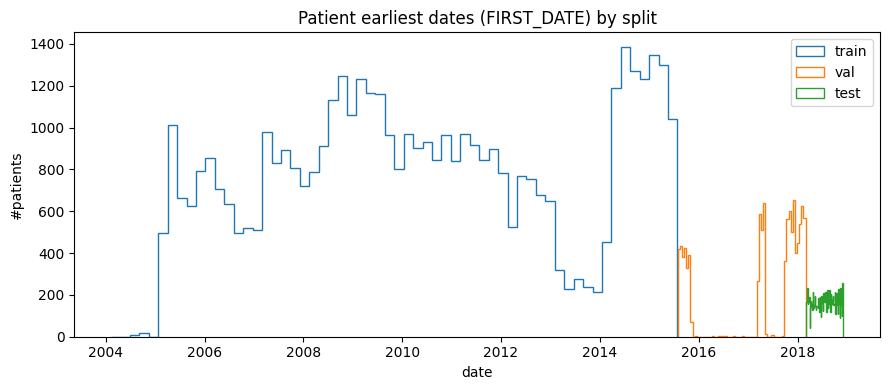

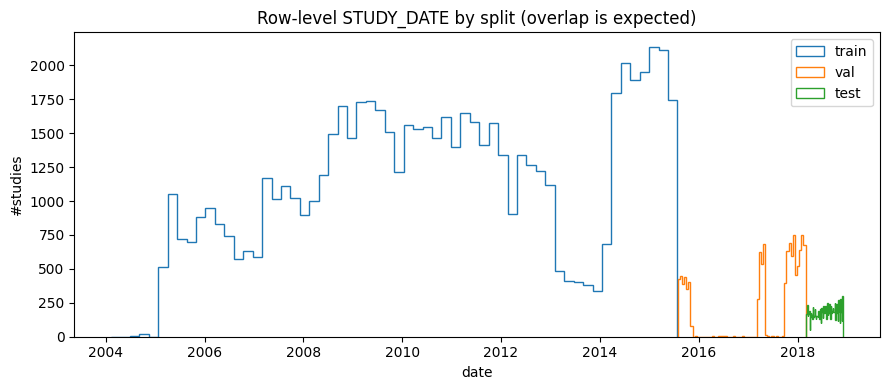

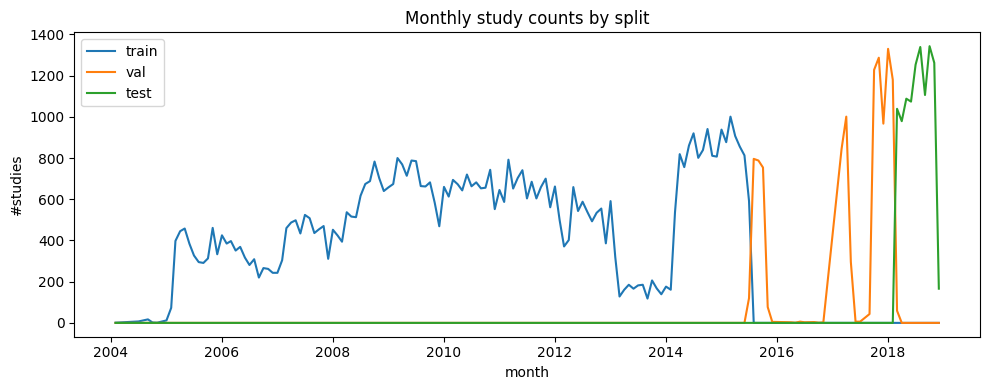

In [67]:
import matplotlib.pyplot as plt

# A) Histograms of patient FIRST_DATE per split
plt.figure(figsize=(9,4))
for s, lab in [(e_train["FIRST_DATE"], "train"),
               (e_val["FIRST_DATE"],   "val"),
               (e_test["FIRST_DATE"],  "test")]:
    plt.hist(pd.to_datetime(s), bins=60, histtype="step", label=lab)
plt.title("Patient earliest dates (FIRST_DATE) by split")
plt.xlabel("date"); plt.ylabel("#patients"); plt.legend(); plt.tight_layout()
plt.show()

# B) Row-level STUDY_DATE distributions (overlap expected; patients have follow-ups)
plt.figure(figsize=(9,4))
for df, lab in [(tr, "train"), (va, "val"), (te, "test")]:
    plt.hist(pd.to_datetime(df["STUDY_DATE"]), bins=60, histtype="step", label=lab)
plt.title("Row-level STUDY_DATE by split (overlap is expected)")
plt.xlabel("date"); plt.ylabel("#studies"); plt.legend(); plt.tight_layout()
plt.show()

# C) Monthly counts per split (time series)
monthly = (all_splits
           .assign(MONTH=pd.to_datetime(all_splits["STUDY_DATE"]).dt.to_period("M").dt.to_timestamp())
           .groupby(["SPLIT","MONTH"]).size()
           .unstack(0).fillna(0))

plt.figure(figsize=(10,4))
plt.plot(monthly.index, monthly.get("train", 0), label="train")
plt.plot(monthly.index, monthly.get("val",   0), label="val")
plt.plot(monthly.index, monthly.get("test",  0), label="test")
plt.title("Monthly study counts by split")
plt.xlabel("month"); plt.ylabel("#studies"); plt.legend(); plt.tight_layout()
plt.show()


In [37]:
a4c_dataset.to_csv(f"csv/a4c_{label_col}.csv")

In [38]:
import pandas as pd

def build_temporal_patient_splits(
    df,
    label_mapping,
    label_col,
    date_col="STUDY_DATE",
    patient_col="PATIENT_ID",
    train_frac=0.70,
    val_frac=0.15,              # test = 1 - train - val
    anchor="min",               # 'min' | 'median' | 'max' patient date to order by
    enforce_time_windows=True,  # drop rows outside each split’s time window
):
    assert 0 < train_frac < 1 and 0 < val_frac < 1 and train_frac + val_frac < 1
    d = df.copy()

    # labels → ints
    num_col = f"{label_col}_numeric"
    d[num_col] = d[label_col].map(label_mapping)

    # dates
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col, num_col, patient_col])

    # ----- patient-level temporal ordering -----
    stats = d.groupby(patient_col)[date_col].agg(["min", "median", "max"])
    anchor_series = stats[anchor].sort_values()  # one timestamp per patient, ordered
    patients = anchor_series.index.to_list()

    n = len(patients)
    cut1 = int(n * train_frac)
    cut2 = int(n * (train_frac + val_frac))

    train_p = set(patients[:cut1])
    val_p   = set(patients[cut1:cut2])
    test_p  = set(patients[cut2:])

    train_df = d[d[patient_col].isin(train_p)]
    val_df   = d[d[patient_col].isin(val_p)]
    test_df  = d[d[patient_col].isin(test_p)]

    # optional: strictly enforce temporal windows by date (no cross-window rows)
    if enforce_time_windows:
        # windows from global item-level dates
        q1 = d[date_col].quantile(train_frac)
        q2 = d[date_col].quantile(train_frac + val_frac)
        train_df = train_df[train_df[date_col] < q1]
        val_df   = val_df[(val_df[date_col] >= q1) & (val_df[date_col] < q2)]
        test_df  = test_df[test_df[date_col] >= q2]

    # safety: no patient leakage
    assert not (set(train_df[patient_col]) & set(val_df[patient_col]))
    assert not (set(train_df[patient_col]) & set(test_df[patient_col]))
    assert not (set(val_df[patient_col])   & set(test_df[patient_col]))

    return train_df, val_df, test_df


In [39]:
print(a4c_dataset[label_col].value_counts())

# Create mapping automatically from unique labels
label_mapping = {label: idx 
                 for idx, label in enumerate(sorted(a4c_dataset[label_col].unique()))}

print(label_mapping)

LA_Dilated_Binary
normal     854928
dilated    203887
Name: count, dtype: int64
{'dilated': 0, 'normal': 1}


In [40]:
print(f"a4c_{label_col}_train.csv")

a4c_LA_Dilated_Binary_train.csv


In [42]:
train_df, val_df, test_df = build_temporal_patient_splits(a4c_dataset, label_mapping, label_col)

num_col = f"{label_col}_numeric"   # e.g., 'Dilated_Binary_numeric'

train_df[['URI', num_col]].to_csv(f"csv/a4c_{label_col}_train.csv", header=False, index=False, sep=' ')
val_df[['URI', num_col]].to_csv(  f"csv/a4c_{label_col}_val.csv",   header=False, index=False, sep=' ')
test_df[['URI', num_col]].to_csv( f"csv/a4c_{label_col}_test.csv",  header=False, index=False, sep=' ')

  
# Print split statistics  
print(f"Total samples: {len(a4c_dataset)}")  
print(f"Train: {len(train_df)} ({len(train_df)/len(a4c_dataset)*100:.1f}%)")  
print(f"Validation: {len(val_df)} ({len(val_df)/len(a4c_dataset)*100:.1f}%)")  
print(f"Test: {len(test_df)} ({len(test_df)/len(a4c_dataset)*100:.1f}%)")  
  
# Print label distribution for each split  
print("\nLabel distribution:")  
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:  
    print(f"{split_name}:")  
    for label, count in split_df[num_col].value_counts().sort_index().items():  
        original_label = [k for k, v in label_mapping.items() if v == label][0]  
        print(f"  {label} ({original_label}): {count}")  

Total samples: 1058815
Train: 739147 (69.8%)
Validation: 112119 (10.6%)
Test: 123472 (11.7%)

Label distribution:
Train:
  0 (dilated): 131653
  1 (normal): 607494
Val:
  0 (dilated): 22011
  1 (normal): 90108
Test:
  0 (dilated): 27909
  1 (normal): 95563



Train year counts:
STUDY_DATE
2004      291
2005    35296
2006    36270
2007    54094
2008    77169
2009    88059
2010    82523
2011    83753
2012    65999
2013    27292
2014    91203
2015    97198


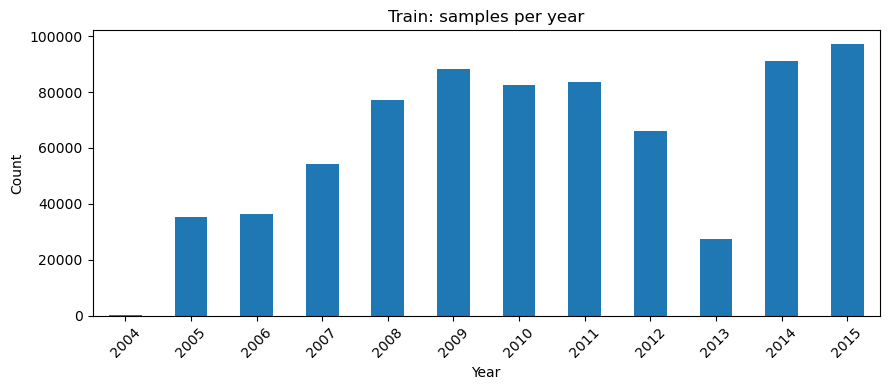


Validation year counts:
STUDY_DATE
2015      741
2016      231
2017    60184
2018    50963


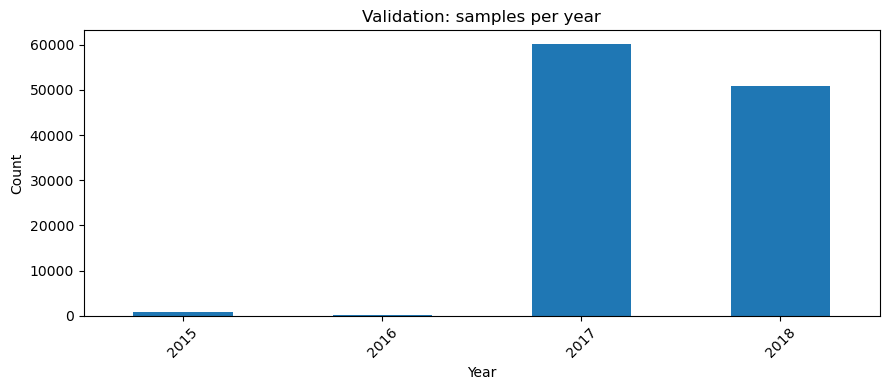


Test year counts:
STUDY_DATE
2018    123472


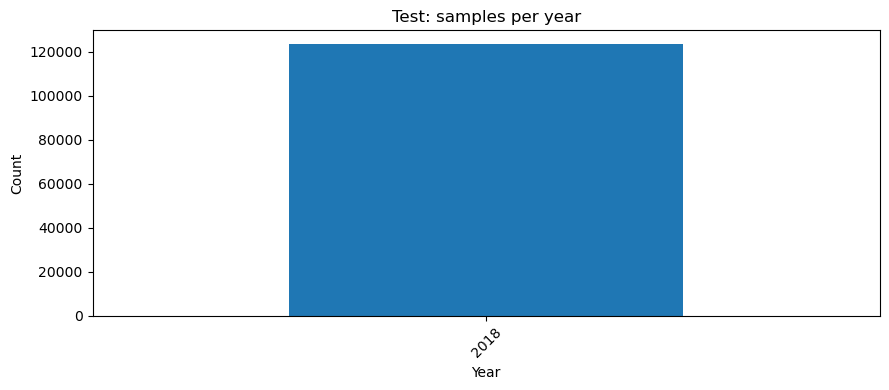

In [43]:
import matplotlib.pyplot as plt

date_col = "STUDY_DATE"
num_col  = f"{label_col}_numeric"

def year_hist(df, title):
    years = pd.to_datetime(df[date_col], errors="coerce").dt.year.dropna().astype(int)
    counts = years.value_counts().sort_index()

    # print table
    print(f"\n{title} year counts:")
    print(counts.to_string())

    # plot one chart per split
    plt.figure(figsize=(9,4))
    counts.plot(kind="bar")
    plt.title(f"{title}: samples per year")
    plt.xlabel("Year"); plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

year_hist(train_df, "Train")
year_hist(val_df,   "Validation")
year_hist(test_df,  "Test")